# Regressão Polinomial

Previsão do preço do aluguel do imóvel com base em variáveis do banco (exceto as avaliadas anteriormente, valor do condimínio e metragem).

## Configurações gerais

In [137]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

import numpy as np

from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [138]:
df = pd.read_csv('ALUGUEL_MOD12.csv', delimiter = ';')
df.head(3)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1


## Pré-Processamento

A base de dados usada já está tratada. Ainda assim, para conhecer a base e não perder o hábito de aplicar o pré-processamento, foram investigadas algumas caracaterísticas da base. São elas:
- Não há valores nulos.
- Todas as variáveis tem tipos adequados.
- Apesar da análise objetiva do IQR indicar a presença de outliers, o perfil diverso do banco cria a possibilidade de valores (reais) muito discrepantes.
- Os valores mínimos e máximos tem um comportamento compatível com a realidade.

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [140]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [141]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [142]:
diqr = pd.DataFrame(columns=['min', 'max', 'upper_bound'])

for campo in df.columns:
    q1 = df[campo].quantile(0.25)
    q3 = df[campo].quantile(0.75)
    iqr = q3 - q1
    # lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    diqr.loc[campo] = [df[campo].min(), df[campo].max(), upper_bound]

print(diqr)

                    min      max  upper_bound
Valor_Aluguel     480.0  25000.0       5975.0
Valor_Condominio    0.0   9500.0       1857.5
Metragem           30.0    880.0        172.0
N_Quartos           1.0     10.0          4.5
N_banheiros         1.0      8.0          2.0
N_Suites            0.0      5.0          1.0
N_Vagas             0.0      9.0          3.5


## Escolha da variável


Para escolher a variável, foi analisada a matriz de correlação com a variável a alvo valor de aluguel. A variável número de vagas foi escolhida pois possui o maior índice de correlação, com exceção das váriaveis da metragem e valor do condomínop, previamente analisadas.



In [143]:
df.corr().iloc[0].sort_values(ascending=False)

Valor_Aluguel       1.000000
Metragem            0.730591
Valor_Condominio    0.695302
N_Vagas             0.652858
N_Suites            0.614397
N_banheiros         0.603715
N_Quartos           0.413139
Name: Valor_Aluguel, dtype: float64

## Separação das bases para Regressão Polinomial

In [144]:
y = df['Valor_Aluguel']
x = df[['N_Vagas']]
poly_features = PolynomialFeatures(degree=2)
x_poly = poly_features.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

if (x_train.shape[0] != y_train.shape[0]) or (x_test.shape[0] != y_test.shape[0]): 
    print('Erro na separação dsd bases.')
else:
    print('Separação de bases de treino finalizada com sucesso.')



Separação de bases de treino finalizada com sucesso.


## Treinamento do Modelo

### Polinomio de grau 2

A curva obtida pelo modelo tem o comportamento esperado de uma curva de segundo grau positiva.Ela se adapta bem ao comportamento de crescimento até 4 vagas. A partir de 5 vagas a taxa de crescimento do valor do aluguel diminui, indicando uma derivada negativa. Por esse motiva, imagina-se que o polinomio mais ajsutado aos dados deve ter uma inversão no crescimento em y, alterando o sinal da derivada. Polinomios de grau 4 e 6 apresentam um comportamento mais aproximado ao que se deseja.

In [145]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_2 = model.predict(x_test)
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) 
x_range_poly = poly_features.transform(x_range)
# transformação polinomial necessária para a predição.
y_range_pred_2 = model.predict(x_range_poly)


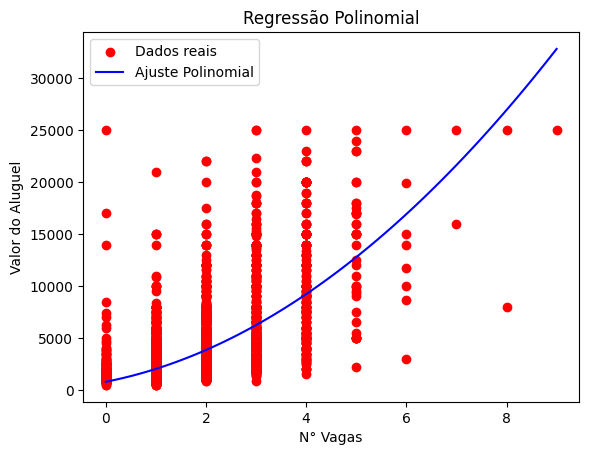

In [146]:

plt.scatter(x, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred_2, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('N° Vagas')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

### Polinomio de grau 4

Como é possível verificar no gráfico, a curva se adapata melhor aos dados do que o polinomio de grau 2.

Separação de bases de treino finalizada com sucesso.


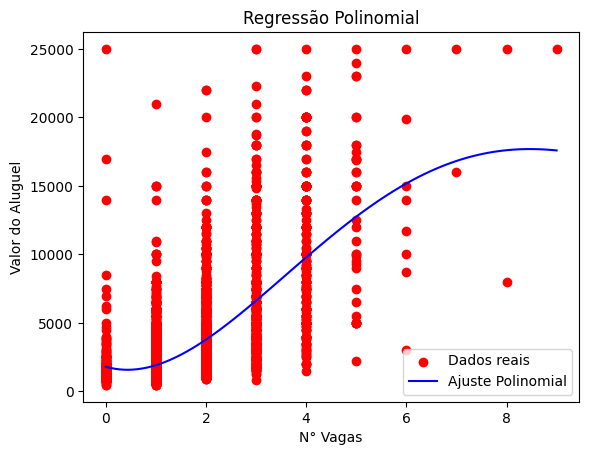

In [147]:
# y = df['Valor_Aluguel']
# x = df[['N_Vagas']]
poly_features = PolynomialFeatures(degree=4)
x_poly = poly_features.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

if (x_train.shape[0] != y_train.shape[0]) or (x_test.shape[0] != y_test.shape[0]): 
    print('Erro na separação dsd bases.')
else:
    print('Separação de bases de treino finalizada com sucesso.')

model = LinearRegression()
model.fit(x_train, y_train)
y_pred_4 = model.predict(x_test)
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) 
x_range_poly = poly_features.transform(x_range)
# transformação polinomial necessária para a predição.
y_range_pred_4 = model.predict(x_range_poly)


plt.scatter(x, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred_4, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('N° Vagas')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()


### Polinômio de grau 6


Visualmente, o polinomio de grau 6 parece se ajustar melhor aos dados do que o 4, pois o ponto de inversão da curva, de derivada zero, parece estar bem ajustado.  

Separação de bases de treino finalizada com sucesso.


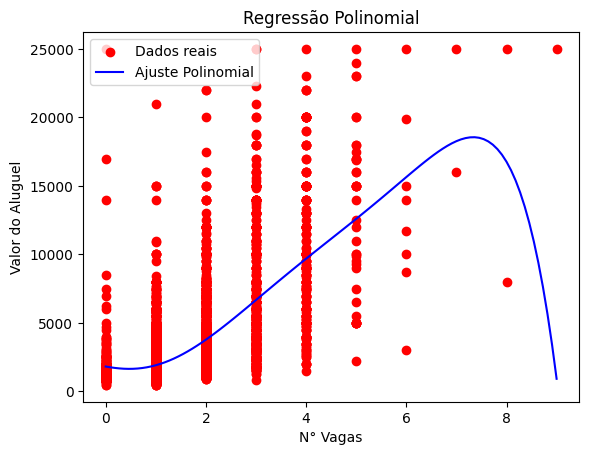

In [148]:
# y = df['Valor_Aluguel']
# x = df[['N_Vagas']]
poly_features = PolynomialFeatures(degree=6)
x_poly = poly_features.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

if (x_train.shape[0] != y_train.shape[0]) or (x_test.shape[0] != y_test.shape[0]): 
    print('Erro na separação dsd bases.')
else:
    print('Separação de bases de treino finalizada com sucesso.')

model = LinearRegression()
model.fit(x_train, y_train)
y_pred_6 = model.predict(x_test)
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) 
x_range_poly = poly_features.transform(x_range)
# transformação polinomial necessária para a predição.
y_range_pred_6 = model.predict(x_range_poly)


plt.scatter(x, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred_6, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('N° Vagas')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()


## Avaliação de 

Os valores listados abaixo indicam um resultado diferente do discutido a partir da análise visual dos gráficos. Segundo eles, as predições dos modelos de 2° e 4° são igualmente ajustas aos dados, enquanto a de 6° apresenta um comportamente levemente inferior.

Esse resultado levanta a questão de revisão da aplicação do modelo e do cálculo do R² antes da tomada de decisões.

In [149]:
r2 = r2_score(y_test, y_pred_2)
print(f'R² da Regressão Polinomial 2°: {r2:.4f}')
r2 = r2_score(y_test, y_pred_4)
print(f'R² da Regressão Polinomial 4°: {r2:.4f}')
r2 = r2_score(y_test, y_pred_6)
print(f'R² da Regressão Polinomial 6°: {r2:.4f}')

R² da Regressão Polinomial 2°: 0.4907
R² da Regressão Polinomial 4°: 0.4998
R² da Regressão Polinomial 6°: 0.4605


# Mais técnicas de regressão polinomial

Elastic Net, Ridge e Lasso são técnicas de *regularização* usadas para evitar overfitting em modelos de regressão polinomial, adicionando penalizações aos coeficientes das variáveis.

**Ridge** aplica uma penalidade L2, que reduz os coeficientes de todas as variáveis, mas não os anula. É eficaz quando todas as variáveis são relevantes, mas precisam ser suavizadas.

**Lasso** usa penalidade L1, que pode zerar coeficientes de variáveis irrelevantes, realizando seleção automática de variáveis e deixando o modelo mais simples e interpretável.

**Elastic Net** combina as penalidades L1 e L2, unindo as vantagens de Ridge e Lasso — reduz coeficientes e realiza seleção de variáveis ao mesmo tempo. É útil quando há muitas variáveis correlacionadas.

# Dicas de melhoria para o modelo

- A técnica de oversampling (SMOTENC) é ideal para classificação (problemas supervisionados), não para clustering (não supervisionado), pois cria pontos sintéticos que podem distorcer a estrutura natural dos clusters no espaço original. Para clustering, é melhor aceitar a distribuição real dos dados ou usar métodos que dão pesos diferentes a clusters menores (como o DBSCAN ou técnicas de hierarchical clustering). Mantenha o foco em K-Means apenas com os dados originais e limpos (sem SMOTE), focando na validação do número de clusters (e.g., usando o Método do Cotovelo na inércia, que não foi mostrado explicitamente, mas é essencial).

- Para visualizar melhor que não há diferença de concentração de Gender nos clusters de forma mais quantitativa (e não apenas visual), crar um gráfico de barras ou heatmap que mostre a proporção ou contagem de Male vs Female por cluster final. Isso ajuda a documentar a ausência de viés de gênero na segmentação de forma numérica e visualmente concisa.